# Finding Optimal Lags
### Authors Andy Jiang & Collin McDevitt


In [15]:
%pip install neuralforecast yfinance matplotlib pandas numpy statsmodels pmdarima scikit-learn darts setuptools
%pip install --upgrade "packaging<24.0" setuptools
%pip install transformers tokenizers -U
%pip install arch

  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
Using cached packaging-26.0-py3-none-any.whl (74 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 23.2
    Uninstalling packaging-23.2:
      Successfully uninstalled packaging-23.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.7.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
  Using cached packaging-23.2-py3-none-any.whl.metadata (3.2 kB)
Using cached packaging-23.2-py3-none-any.whl (53 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are insta

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas_datareader import data as pdr

import yfinance as yf
from darts import TimeSeries

from darts.models import NBEATSModel, NHiTSModel

from darts.dataprocessing.transformers import Scaler

from darts.metrics import rmse
import pmdarima as pm
from sklearn.metrics import mean_squared_error

from fredapi import Fred


from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

import seaborn as sns


from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit


from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import itertools
import warnings
warnings.filterwarnings("ignore")


In [17]:
# Loading Data
df = pd.read_csv("dataframe.csv", parse_dates=["ds"]).sort_values("ds")
df = df.set_index("ds")


In [18]:
print("Shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print("Duplicate dates:", df.index.duplicated().sum())
print("Missing values:\n", df.isna().sum())


Shape: (5787, 9)
Date range: 2003-01-02 00:00:00 to 2025-12-31 00:00:00
Duplicate dates: 0
Missing values:
 y                0
vix              0
EPU              0
UMCSENT          0
JOBLESS          0
FEDFUNDS         0
FLOWS            0
CPI              0
inflation_yoy    0
dtype: int64


In [19]:
desc = df.describe().T
desc["median"] = df.median()
desc["skew"] = df.skew()
desc["kurtosis"] = df.kurtosis()
desc["missing"] = df.isna().sum()
print(desc[["count","missing","mean","median","std","min","25%","50%","75%","max","skew","kurtosis"]])



                count  missing           mean         median            std  \
y              5787.0        0     149.883667      85.314064     149.077309   
vix            5787.0        0      19.108573      16.799999       8.400969   
EPU            5787.0        0     123.440994      94.650000      99.658154   
UMCSENT        5787.0        0      80.103093      81.200000      13.397310   
JOBLESS        5787.0        0  370398.306549  316000.000000  364682.644022   
FEDFUNDS       5787.0        0       1.755562       1.010000       1.889847   
FLOWS          5787.0        0      71.794510      35.430000     108.699661   
CPI            5787.0        0     240.896074     236.222000      38.084692   
inflation_yoy  5787.0        0       0.083481       0.000000       0.220864   

                         min            25%            50%            75%  \
y                  20.102076      38.302954      85.314064     212.231270   
vix                 9.140000      13.605000      16.799

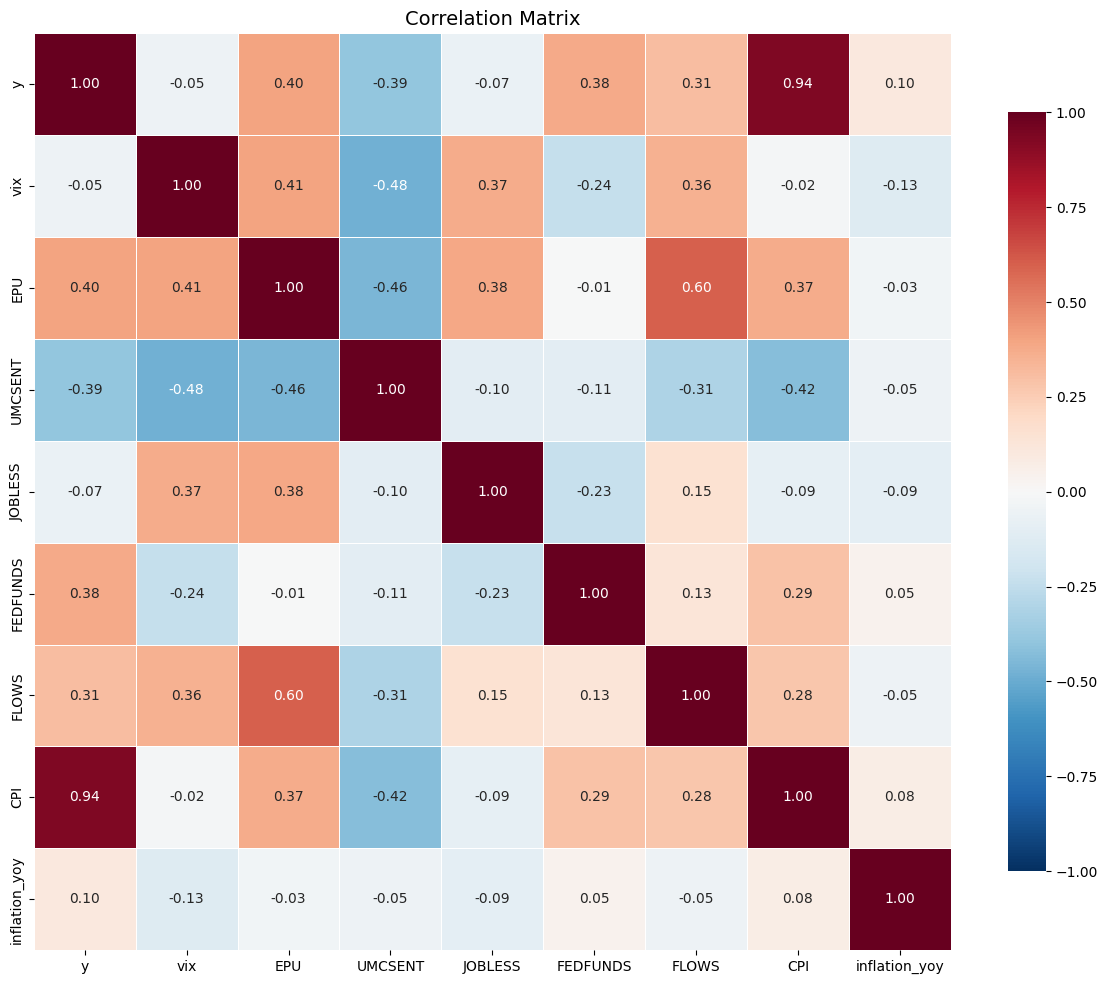


Lagged correlations with y:
                   lag_0     lag_1     lag_2     lag_3     lag_4     lag_5  \
vix           -0.049753 -0.048950 -0.048401 -0.047656 -0.046929 -0.046289   
EPU            0.404911  0.404842  0.404910  0.404176  0.403255  0.403354   
UMCSENT       -0.391710 -0.391082 -0.390446 -0.389781 -0.389110 -0.388458   
JOBLESS       -0.068740 -0.067779 -0.066908 -0.065924 -0.065048 -0.064074   
FEDFUNDS       0.376125  0.376055  0.375980  0.375910  0.375840  0.375771   
FLOWS          0.306736  0.306774  0.307252  0.306180  0.306111  0.306922   
CPI            0.936806  0.936761  0.936714  0.936670  0.936628  0.936585   
inflation_yoy  0.102814  0.102671  0.102566  0.102754  0.102753  0.102700   

                  lag_6     lag_7     lag_8     lag_9    lag_10  
vix           -0.045645 -0.045067 -0.044446 -0.044140 -0.043641  
EPU            0.403994  0.404620  0.404136  0.403997  0.404367  
UMCSENT       -0.387830 -0.387193 -0.386610 -0.386040 -0.385432  
JOBLESS     

In [20]:

import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

max_lag = 10
lag_corrs = {}
for col in df.columns:
    if col != "y":
        lag_corrs[col] = {
            f"lag_{lag}": df["y"].corr(df[col].shift(lag))
            for lag in range(max_lag + 1)
        }

lag_corrs_df = pd.DataFrame(lag_corrs).T
print("\nLagged correlations with y:\n", lag_corrs_df)

We can see a lot of correlation, but this is simply because everything trends upward over time. We need to look at the percentage change in
$y$ instead.

In [ ]:
from statsmodels.tsa.stattools import adfuller, ccf


df["y_log_ret"] = np.log(df["y"]).diff()
df["y_pct_change"] = df["y"].pct_change()

df.corr()



,y,vix,EPU,UMCSENT,JOBLESS,FEDFUNDS,FLOWS,CPI,inflation_yoy,y_log_ret,...,CPI_diff,vix_lag1,EPU_lag2,UMCSENT_diff_lag10,JOBLESS_lag3,FEDFUNDS_diff_lag10,FLOWS_lag26,CPI_diff_lag10,inflation_yoy_lag21,realized_vol
y,1.000000,-0.049753,0.404911,-0.391710,-0.068740,0.376125,0.306736,0.936806,0.102814,0.014551,...,0.054279,-0.048950,0.404910,-0.010086,-0.065924,0.005281,0.312394,0.054694,0.100624,0.001377
vix,-0.049753,1.000000,0.405489,-0.477320,0.374333,-0.235535,0.356730,-0.022103,-0.131802,-0.126752,...,-0.036045,0.975875,0.387902,-0.048121,0.347316,-0.097142,0.228925,-0.052129,-0.106948,0.453377
EPU,0.404911,0.405489,1.000000,-0.456569,0.384056,-0.006376,0.601345,0.371317,-0.033385,0.030638,...,0.000180,0.413082,0.704022,-0.033947,0.379363,-0.048058,0.397572,-0.007206,-0.039821,0.170173
UMCSENT,-0.391710,-0.477320,-0.456569,1.000000,-0.101585,-0.109127,-0.307089,-0.423455,-0.047624,0.004219,...,-0.026824,-0.479315,-0.459191,0.040627,-0.108674,0.014170,-0.304570,-0.026788,-0.064371,-0.134354
JOBLESS,-0.068740,0.374333,0.384056,-0.101585,1.000000,-0.231729,0.149287,-0.092331,-0.094324,0.044885,...,-0.038501,0.385345,0.394280,-0.032953,0.960880,-0.047607,0.208899,-0.034384,-0.115317,0.091273
FEDFUNDS,0.376125,-0.235535,-0.006376,-0.109127,-0.231729,1.000000,0.130964,0.294263,0.045855,-0.000923,...,0.019402,-0.236584,-0.008727,-0.005059,-0.234269,0.014197,0.115021,0.019344,0.053870,-0.038639
FLOWS,0.306736,0.356730,0.601345,-0.307089,0.149287,0.130964,1.000000,0.278720,-0.049476,-0.015873,...,-0.009497,0.354886,0.473334,-0.048681,0.137406,-0.031782,0.297755,-0.004476,-0.023586,0.251413
CPI,0.936806,-0.022103,0.371317,-0.423455,-0.092331,0.294263,0.278720,1.000000,0.075631,0.005600,...,0.046815,-0.022105,0.370128,-0.008735,-0.092346,0.013199,0.269709,0.046578,0.079340,0.018552
inflation_yoy,0.102814,-0.131802,-0.033385,-0.047624,-0.094324,0.045855,-0.049476,0.075631,1.000000,0.013395,...,0.322438,-0.127934,-0.039016,0.002021,-0.086012,-0.004411,-0.039537,-0.047515,0.521077,-0.065594
y_log_ret,0.014551,-0.126752,0.030638,0.004219,0.044885,-0.000923,-0.015873,0.005600,0.013395,1.000000,...,0.040459,0.036331,0.042014,0.043689,0.043338,0.087146,0.033874,0.049560,-0.028199,-0.050929


In [22]:
df["y_pct_change"] = df["y"].pct_change()
indicators = ["vix", "EPU", "UMCSENT", "JOBLESS", "FEDFUNDS", "FLOWS", "CPI", "inflation_yoy"]

for col in indicators:
    adf_stat, p_val, *_ = adfuller(df[col].dropna())
    print(f"{col}: ADF stat={adf_stat:.3f}, p={p_val:.4f}")



vix: ADF stat=-5.978, p=0.0000
EPU: ADF stat=-4.144, p=0.0008
UMCSENT: ADF stat=-2.337, p=0.1602
JOBLESS: ADF stat=-6.544, p=0.0000
FEDFUNDS: ADF stat=-1.553, p=0.5071
FLOWS: ADF stat=-6.964, p=0.0000
CPI: ADF stat=2.086, p=0.9988
inflation_yoy: ADF stat=-8.815, p=0.0000


# 3 non stationary UMCSENT, FEDFUNDS, CPI

In [23]:

df["UMCSENT_diff"] = df["UMCSENT"].diff()
df["FEDFUNDS_diff"] = df["FEDFUNDS"].diff()
df["CPI_diff"] = df["CPI"].diff()

# Verify they're now stationary
for col in ["UMCSENT_diff", "FEDFUNDS_diff", "CPI_diff"]:
    adf_stat, p_val, *_ = adfuller(df[col].dropna())
    print(f"{col}: ADF stat={adf_stat:.3f}, p={p_val:.4f}")


indicators_final = [
    "vix", "EPU", "UMCSENT_diff", "JOBLESS",
    "FEDFUNDS_diff", "FLOWS", "CPI_diff", "inflation_yoy"
]


max_lag = 30
best_lags = {}

for col in indicators_final:
    correlations = []
    for lag in range(1, max_lag + 1):
        corr = df["y_log_ret"].corr(df[col].shift(lag))
        correlations.append((lag, abs(corr), corr))
    
    best = max(correlations, key=lambda x: x[1])
    best_lags[col] = {"best_lag": best[0], "abs_corr": round(best[1], 4), "corr": round(best[2], 4)}

best_lags_df = pd.DataFrame(best_lags).T.sort_values("abs_corr", ascending=False)
print(best_lags_df)

UMCSENT_diff: ADF stat=-76.048, p=0.0000
FEDFUNDS_diff: ADF stat=-7.156, p=0.0000
CPI_diff: ADF stat=-9.084, p=0.0000
               best_lag  abs_corr    corr
FEDFUNDS_diff      10.0    0.0871  0.0871
CPI_diff           10.0    0.0496  0.0496
UMCSENT_diff       10.0    0.0437  0.0437
JOBLESS             3.0    0.0433  0.0433
EPU                 2.0    0.0420  0.0420
vix                 1.0    0.0363  0.0363
FLOWS              26.0    0.0339  0.0339
inflation_yoy      21.0    0.0282 -0.0282


# Even with optimal lags selected to maximize the absolute correlation, the values remain near zero. This indicates the earlier correlations were still spurious.

In [24]:

lag_map = {
    "vix": 1,         
    "EPU": 2,
    "UMCSENT_diff": 10,
    "JOBLESS": 3,
    "FEDFUNDS_diff": 10,
    "FLOWS": 26,
    "CPI_diff": 10,
    "inflation_yoy": 21,
}

for col, lag in lag_map.items():
    df[f"{col}_lag{lag}"] = df[col].shift(lag)

exog_cols = [f"{col}_lag{lag}" for col, lag in lag_map.items()]


df_model = df[["y_log_ret"] + exog_cols].dropna()


split = int(len(df_model) * 0.8)
train = df_model.iloc[:split]
test = df_model.iloc[split:]

endog_train = train["y_log_ret"]
exog_train = train[exog_cols]
endog_test = test["y_log_ret"]
exog_test = test[exog_cols]


p_range = range(0, 4)
d_range = [0]  
q_range = range(0, 4)

best_aic = np.inf
best_order = None

for p, d, q in itertools.product(p_range, d_range, q_range):
    try:
        model = SARIMAX(endog_train, exog=exog_train, order=(p, d, q),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=False, maxiter=200)
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, d, q)
            print(f"  New best: ({p},{d},{q}) AIC={results.aic:.2f}")
    except Exception:
        continue

print(f"\nBest order: {best_order}, AIC: {best_aic:.2f}")


model = SARIMAX(endog_train, exog=exog_train, order=best_order,
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)
print(results.summary())


preds = results.forecast(steps=len(test), exog=exog_test)

rmse = np.sqrt(mean_squared_error(endog_test, preds))
mae = mean_absolute_error(endog_test, preds)
print(f"\nTest RMSE: {rmse:.6f}")
print(f"Test MAE:  {mae:.6f}")

  New best: (0,0,0) AIC=7532.71
  New best: (0,0,1) AIC=-26755.28
  New best: (1,0,0) AIC=-26761.56

Best order: (1, 0, 0), AIC: -26761.56
                               SARIMAX Results                                
Dep. Variable:              y_log_ret   No. Observations:                 4608
Model:               SARIMAX(1, 0, 0)   Log Likelihood               13390.780
Date:                Fri, 13 Mar 2026   AIC                         -26761.559
Time:                        21:39:32   BIC                         -26697.206
Sample:                             0   HQIC                        -26738.911
                               - 4608                                         
Covariance Type:                  opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
vix_lag1            -5.425e-06    1.1e-05     -0.494 

In [25]:
rmse_naive = np.sqrt(mean_squared_error(endog_test, np.zeros(len(endog_test))))


model_ar1 = SARIMAX(endog_train, order=(1, 0, 0),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
results_ar1 = model_ar1.fit(disp=False)
preds_ar1 = results_ar1.forecast(steps=len(test))
rmse_ar1 = np.sqrt(mean_squared_error(endog_test, preds_ar1))

print(f"SARIMAX + exog RMSE: {rmse:.8f}")
print(f"AR(1) only RMSE:     {rmse_ar1:.8f}")
print(f"Naive (zero) RMSE:   {rmse_naive:.8f}")

SARIMAX + exog RMSE: 0.01435470
AR(1) only RMSE:     0.01430201
Naive (zero) RMSE:   0.01430207


The AR(1) model without exogenous regressors produced the lowest test RMSE, marginally outperforming the naive forecast. Adding lagged macro indicators worsened out-of-sample performance, suggesting the model overfits to spurious in-sample relationships. Daily QQQ log returns are well-approximated by a random walk, consistent with weak-form market efficiency.

In [26]:
from arch import arch_model
import numpy as np
import pandas as pd

# 1. Compute realized volatility proxy (squared log returns)
df["y_log_ret"] = np.log(df["y"]).diff()
df["realized_vol"] = df["y_log_ret"] ** 2

# 2. Fit a baseline GARCH(1,1) with no exogenous variables
am_base = arch_model(df["y_log_ret"].dropna() * 100,  # scale up for numerical stability
                     vol="Garch", p=1, q=1, mean="AR", lags=1)
res_base = am_base.fit(disp="off")
print(res_base.summary())

# 3. Fit GARCH(1,1) with exogenous variables in the variance equation
# arch package allows exogenous regressors via the volatility process
# But it's easier to use a two-step approach:

# Step A: Fit GARCH(1,1), extract conditional variance
cond_vol = res_base.conditional_volatility

# Step B: Regress conditional variance on lagged macro indicators
from statsmodels.api import OLS, add_constant

# Use your stationary indicators with optimal lags
vol_df = pd.DataFrame({
    "cond_vol": cond_vol,
    "vix_lag1": df["vix"].shift(1),
    "EPU_lag2": df["EPU"].shift(2),
    "FEDFUNDS_diff_lag10": df["FEDFUNDS_diff"].shift(10),
    "JOBLESS_lag3": df["JOBLESS"].shift(3),
    "CPI_diff_lag10": df["CPI_diff"].shift(10),
    "FLOWS_lag1": df["FLOWS"].shift(1),
}).dropna()

X = add_constant(vol_df.drop(columns="cond_vol"))
y = vol_df["cond_vol"]

split = int(len(vol_df) * 0.8)
reg = OLS(y.iloc[:split], X.iloc[:split]).fit()
print(reg.summary())

# Step C: Compare out-of-sample
preds_base = cond_vol.iloc[split:]
preds_exog = reg.predict(X.iloc[split:])

from sklearn.metrics import mean_squared_error
realized = (df["y_log_ret"].dropna() * 100).iloc[split:] ** 2

# Align indices
common_idx = preds_base.index.intersection(preds_exog.index).intersection(realized.index)

rmse_base = np.sqrt(mean_squared_error(realized.loc[common_idx], preds_base.loc[common_idx]))
rmse_exog = np.sqrt(mean_squared_error(realized.loc[common_idx], preds_exog.loc[common_idx]))
print(f"\nGARCH(1,1) baseline RMSE: {rmse_base:.4f}")
print(f"GARCH + macro regressors RMSE: {rmse_exog:.4f}")

                           AR - GARCH Model Results                           
Dep. Variable:              y_log_ret   R-squared:                       0.003
Mean Model:                        AR   Adj. R-squared:                  0.003
Vol Model:                      GARCH   Log-Likelihood:               -9034.67
Distribution:                  Normal   AIC:                           18079.3
Method:            Maximum Likelihood   BIC:                           18112.6
                                        No. Observations:                 5785
Date:                Fri, Mar 13 2026   Df Residuals:                     5783
Time:                        21:39:33   Df Model:                            2
                                   Mean Model                                  
                   coef    std err          t      P>|t|       95.0% Conf. Int.
-------------------------------------------------------------------------------
Const            0.0969  1.421e-02      6.820  9.